# COMP219
## Lab 5

In the previous weeks, we introduced some basic visualisation techniques and two models: decision trees and k-nearest neighbours. We also looked into some attacks: these were data poisoning and membership inference attacks.

This week, we will introduce linear regression and logistic regression. We will also introduce a new type of attack: model stealing.

### Part 1.1: Linear Regression
Linear regression is a simple mathematical process that aims to find a line of best fit through data points in the dataset. It can help us make predictions on the outcome (dependent) variable using the predictor (independent) variables. Usually, the outcome is of *numeric* type.

In the first part, we will demonstrate how we can build a linear regression model. In a real-life scenario, you would need multiple predictors - our aim is to demonstrate how introducing additional variables will improve model performance. We will pick a numeric variable that is the most strongly-correlated with the outcome and perform a prediction. Then, we will add the remaining variables to improve our model. In this lab, we will use the insurance dataset which you can find [here](https://github.com/stedy/Machine-Learning-with-R-datasets/blob/master/insurance.csv).

In [1]:
#setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

insurance = pd.read_csv("insurance.csv")
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


We can see that our numeric predictors are __age__, __bmi__, and __children__; while our categorical variables are __sex__, __smoker__, and __region__. Let's construct a correlation matrix to find out which numeric variables we should look at. In this step, we will ignore categorical data.

*Note*: this is only an example, you will not need to do this in an actual setting. We just want to visualise the outcome on a single predictor.

In [2]:
insurance_num = insurance[["age", "bmi", "children", "charges"]]
insurance_num.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In the output, we can see that __age__ has the highest correlation coefficience on our outcome variable, __charges__. Let's use age to perform a very basic linear regression task.

In [3]:
x = insurance[["age"]] #predictor
y = insurance["charges"] #outcome

#split the data into training and validation sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

#initialise lin reg model
model = LinearRegression()

#fit the model
model.fit(x_train, y_train)

#predict
predictions = model.predict(x_test)

#print the results
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
r_squared = r2_score(y_test, predictions)

print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R²):", r_squared)

Root Mean Squared Error (RMSE): 11661.21595205864
Mean Absolute Error (MAE): 9173.258196746589
R-squared (R²): 0.12408973539501944


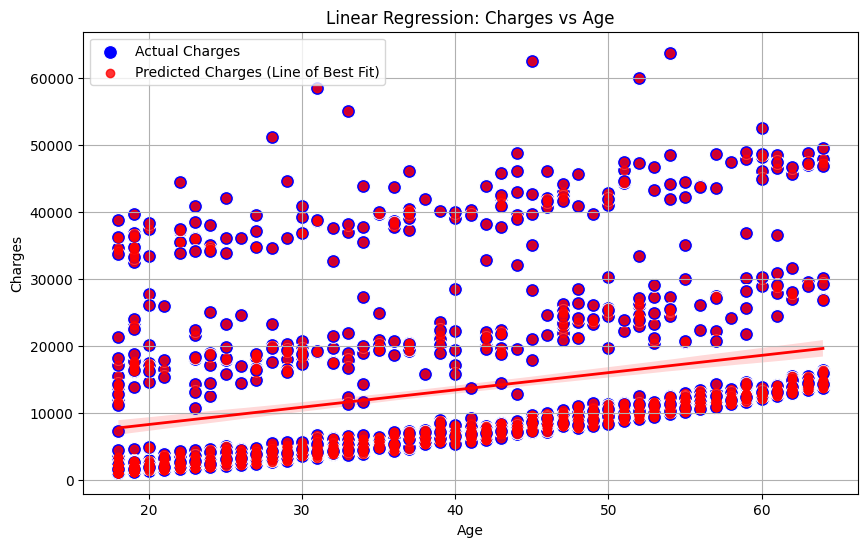

In [4]:
#plot the model with line of best fit
plt.figure(figsize=(10, 6))
sns.scatterplot(data=insurance, x='age', y='charges', color='blue', label='Actual Charges', s=100)  # Actual charges
sns.regplot(data=insurance, x='age', y='charges', color='red', line_kws={"linewidth":2}, label='Predicted Charges (Line of Best Fit)')  # Predicted charges
plt.title('Linear Regression: Charges vs Age')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend()
plt.grid()
plt.show()

#### Explanation of Performance Metrics
__Root Mean Squared Error__: RMSE measures the average magnitude of the errors between the predicted and actual values. Our result for RMSE suggests that on average, the predictions of the insurance charges differ from the actual charges by about £11,661.22. This difference is rather high.

__Mean Absolute Error__: MAE is the average of the absolute differences between predicted and actual values (unlike RMSE, this does not squares the errors). Our MAE result suggests that, on average, our prediction is off by £9,173.26.

__R-squared__: R² is a statistical measure that indicates the proportion of variance in the dependent (outcome) variable that is predictable from the independent variable. This ranges from 0 to 1 with 0 indicating that the predictor explains none of the variability of the outcome, while 1 means it explains all the variability. In our case, we only got 0.124, meaning 12.4% of the insurance charges could be explained by the variable age alone. In other words, only 12.4% of individuals' charges were related to their age only.

Our model does not perform well at all, so we need to introduce other variables. Note that linear regression models can only deal with numeric variables. We will use all of the numeric variables in the dataset as predictors to try to improve model accuracy.

In [5]:
x = insurance[["age", "bmi", "children"]] #predictor
y = insurance["charges"] #outcome

#split the data into training and validation sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

#initialise lin reg model
model = LinearRegression()

#fit the model
model.fit(x_train, y_train)

#predict
predictions = model.predict(x_test)

#print the results
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
r_squared = r2_score(y_test, predictions)

print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R²):", r_squared)

Root Mean Squared Error (RMSE): 11454.315153980095
Mean Absolute Error (MAE): 9181.311632897381
R-squared (R²): 0.15489592484270753


The model performs slightly better but the improvements are not significant. We need to introduce categorical variables. In order to be able to work with categorical data, we need to one-hot encode them. This process splits the data into several columns with each of the categories having its own column (except the last value). For example, smoker will become smoker_yes and it will have either 0 or 1 as an indicator (0 meaning non-smoker, 1 meaning smoker). For a more detailed explanation, have a quick look at [this article](https://machinelearningmastery.com/why-one-hot-encode-data-in-machine-learning/). You will not need to know how to perform this technique from scratch, there is a single function that does this for you in the Pandas library. All you need to know is how to identify categorical variables and then correctly call the function to one-hot encode them.

Here is the complete process of linear regression modelling:

In [6]:
#encode categorical variables
insurance_encoded = pd.get_dummies(data = insurance, columns = ["sex", "smoker", "region"], drop_first = True)

#find out what column names have been created
insurance_encoded.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

In [7]:
#perform lin reg
x = insurance_encoded[["age", "sex_male", "bmi", "children", "smoker_yes", "region_northwest", "region_southeast", "region_southwest"]] #predictor
y = insurance_encoded["charges"] #outcome

#split the data into training and validation sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

#initialise lin reg model
model = LinearRegression()

#fit the model
model.fit(x_train, y_train)

#predict
predictions = model.predict(x_test)

#print the results
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
r_squared = r2_score(y_test, predictions)

print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R²):", r_squared)

Root Mean Squared Error (RMSE): 5796.284659276272
Mean Absolute Error (MAE): 4181.194473753649
R-squared (R²): 0.7835929767120724


Our model performed far better than it did previously. We managed to drastically reduce the RMSE and MAE values while our R² is at 78.4%.

#### __Linear Regression Made Simple__
- Identify the outcome
- Identify categorical variables and one-hot encode them
- x = predictors, y = outcome
- split your dataset (80:20 ratio)
- call the LinearRegression() function to initialise the model.
- fit the model then predict on test set of predictors (x)
- evaluate using RMSE, MAE, and R² metrics (actual values vs predicted values - use test set y and predictions for this)

__Key note:__ linear regression is appropriate for predicting numeric outcomes.

### Part 1.2: Logistic Regression
We can use logistic regression on binary classification problems. Like with linear regression, we can use multiple predictors for predicting a single outcome. The linear regression model's output is continuous - logistic regression instead predicts the probability of the binary values. It uses the sigmoid function to transform the output, ensuring that a possible label is produced. Recall from the lecture notes that the sigmoid function ranges between 0 and 1 on the y-axis - the threshold is often set to 0.5 for predicting a category. For example, if we exceed this threshold in our output, the predicted class will be 1, otherwise the prediction is 0.

In this example, we will use the diabetes dataset we used a few weeks ago.

In [8]:
#setup
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

diabetes = pd.read_csv("diabetes.csv")
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
x = diabetes.drop("Outcome", axis = 1) #all variables except our outcome
y = diabetes["Outcome"]

#split the dataset, 80:20 ratio
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#initialise the model
model = LogisticRegression(max_iter = 1000) #we need to set a cap on the iterations in case we fail to achieve convergence

#fit the model
model.fit(x_train, y_train)

#predict the outcome
y_pred = model.predict(x_test)

#evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}") #accuracy
print(f"Classification report:\n {classification_report(y_test, y_pred)}") #classification report

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix) #confusion matrix

Accuracy: 0.75
Classification report:
               precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

Confusion Matrix:
 [[78 21]
 [18 37]]


#### Explanation of Performance Metrics
- __Accuracy__: our model correctly predicted 75% of the instances in the test data - ideally, we whould be above 90%.
- __Precision__:  no diabetes (0.81) v diabetes (0.64). Our model correctly predicted "no diabetes" 81% of the time but only 64% of the "diabetes" predictions was correct. This means there is a high rate of false positive (incorrectly predicting "diabetes").
- __Recall__: no diabetes (0.79) v diabetes (0.67). Our model correctly identified 79% of actual non-diabetic patients. Only 67% of actual diabetic patients were identified, meaning there was a high rate of false negatives.
- __F1-score__: no diabetes (0.80) v diabetes (0.65). The F1-score balances precision and recall to catch mistakes in our calculations. an F1-score of 1 means there were no mistakes made by the model, while a score of 0 suggests our model failed to identify any of the labels correctly. Our F1-scores were similar to precision and recall, meaning both precision and recall were well-balanced.
- __Support__: the sample size for non-diabetic patients was 99 while the sample size for diabetic patients was 55.

#### __Logistic Regression Made Simple__
- Identify the outcome
- Identify categorical variables and one-hot encode them
- x = predictors, y = outcome
- split your dataset (80:20 ratio)
- call the LogisticRegression() function to initialise the model.
- fit the model then predict on test set of predictors (x)
- evaluate using Accuracy, Precision, Recally, and F-1 Score metrics (actual values vs predicted values - use test set y and predictions for this)

__Key note:__ logistic regression is appropriate for predicting binary outcomes.

### Part 2: Model Stealing
In a model stealing attack, we attempt to recreate or replicate a model by interacting with it, without direct access to its architecture, processes, or training data. We query the model by providing it some input data and observe its outputs (or predictions). We then reconstruct the model using the observed inputs and outputs by fitting a new model to copy the original model.

In our example, we will steal our own linear regression model. We will not need a dataset for this.

#### Step 1: Make Up Some Data and Fit the Model

In [10]:
#make up some data
np.random.seed(42)

x = np.random.rand(10000, 5) #create predictors: 10000 samples, 5 features
y = 3 * x[:, 0] + 2 * x[:, 1] + x[:, 2] + np.random.randn(10000) * 0.1 #create a numeric outcome with some random noise

#create training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

original_model = LinearRegression()
original_model.fit(x_train, y_train)

LinearRegression()

#### Step 2: Query the Original Model

In [11]:
x_steal = np.random.rand(2000, 5) #fewer samples but the number of features must match
y_steal = original_model.predict(x_steal)

#### Step 3: Steal the Model
This step involves training the model using collected data.

In [12]:
stolen_model = LinearRegression()
stolen_model.fit(x_steal, y_steal)

LinearRegression()

#### Step 4: Evaluation of the Stolen Model 
We can evaluate the stolen model using mean squared error (MSE)

In [13]:
y_original_test = original_model.predict(x_test)
y_stolen_test = stolen_model.predict(x_test)

#print the result
mse = mean_squared_error(y_original_test, y_stolen_test)
print("MSE between Target Model and Stolen Model:", mse)

MSE between Target Model and Stolen Model: 1.2861344761178406e-30


#### Interpretation of MSE
Our MSE is 1.0239x10^-30, which is extremely low. We succeeded in reconstructing the model - however, linear regression models are very straightforward and we had a small dataset available to us. More sophisticated models will be more difficult to steal.

## Optional Task: Fit a Logistic Regression Model Then Steal It

For your (optional) task, you will need to fit a regression model and extract some information. Most of the code has been provided for you, you just need to complete it. We assume this is a black-box scenario and we don't know anything about the training data. All we know is that when we query the model, it predicts a binary label - so we can potentially use a logistic regression model.

- __Step 1:__ we create some random data and our outcome will be binary.

- __Step 2:__ we evaluate the model.

- __Step 3 (complete this):__ query the model. For this, we need to generate some random data. Give the variable *num_queries* some (integer) value. Then, get the predictions and probabilities from the target model. Note: you can get the probability using the predict_proba() function.

- __Step 4:__ visualisation. This will only work if you have successfully completed step 3. You should see the results of the target model's predictions and the query of the attacker (what the target model predicts based on the attacker's parameters). Note that we only visualise the first two features.

- __Step 5 (complete this):__ train a surrogate (stolen) model. This requires collecting the output of the query.

- __Step 6 (complete this):__ surrogate model evaluation. We evaluate the stolen model using accuracy score.

- __Step 7:__ visualisation of decision boundaries for both the target and surrogate model. This will run only when you complete all previous steps.

Target Model Accuracy: 0.8566666666666667


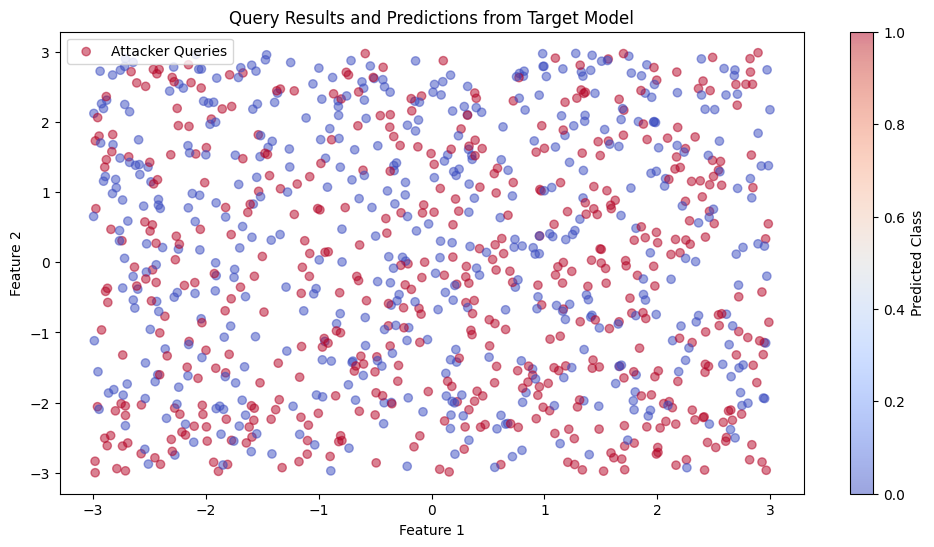

Surrogate Model Accuracy: 0.8533333333333334


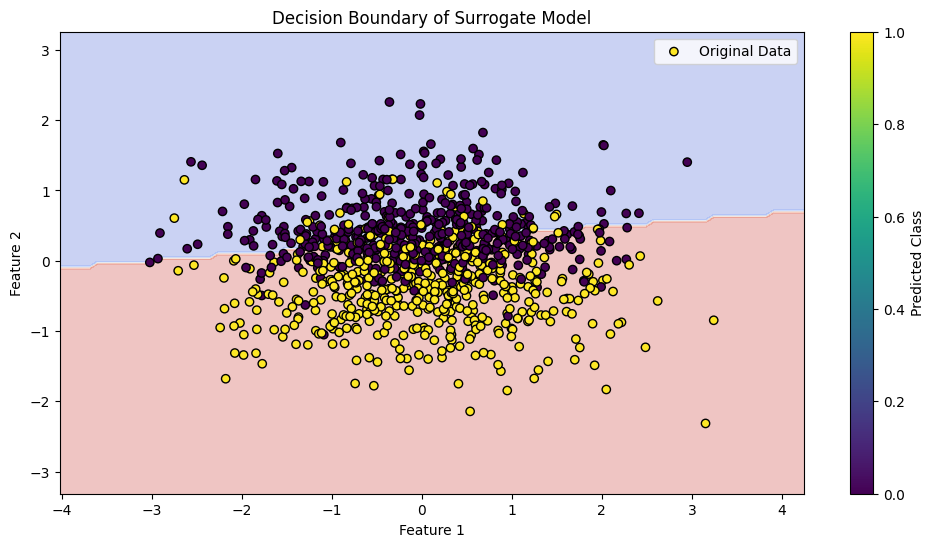

In [14]:
from sklearn.datasets import make_classification

#step 1: create fake data and train the logisitic regression model
x, y = make_classification(n_samples=1000, n_features=5, n_classes=2, n_informative=2, n_redundant=1, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

#train the target model
target_model = LogisticRegression()
target_model.fit(x_train, y_train)

#step 2: evaluate the target model
y_target_pred = target_model.predict(x_test)
target_model_accuracy = accuracy_score(y_test, y_target_pred)
print(f"Target Model Accuracy: {target_model_accuracy}")

#step 3: query the model
#generate random inputs for querying
num_queries = 1000
x_attacker_query = np.random.uniform(low = -3, high = 3, size = (num_queries, 5))

#get predictions and probabilities from the target model
y_attacker_labels = target_model.predict(x_attacker_query)
y_attacker_probs = target_model.predict_proba(x_attacker_query)

#step 4: visualisation
plt.figure(figsize=(12, 6))

#scatter plot of query results
plt.scatter(x_attacker_query[:, 0], x_attacker_query[:, 1], c = y_attacker_labels, cmap = 'coolwarm', alpha = 0.5, label = 'Attacker Queries')
plt.title('Query Results and Predictions from Target Model')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label = 'Predicted Class')
plt.legend()
plt.show()

#step 5: train the surrogate model from collected outputs
surrogate_model = LogisticRegression()
surrogate_model.fit(x_attacker_query, y_attacker_labels)

#step 6: evaluate surrogate model
y_surrogate_pred = surrogate_model.predict(x_test)
print(f"Surrogate Model Accuracy: {accuracy_score(y_test, y_surrogate_pred)}")

#visualisation of decision boundary
x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

mean_other_features = np.mean(x[:, 2:], axis = 0)

mean_other_features_repeated = np.tile(mean_other_features, (xx.ravel().shape[0], 1))

#predictions
z = surrogate_model.predict(np.c_[xx.ravel(), yy.ravel(), mean_other_features_repeated]).reshape(xx.shape)

plt.figure(figsize = (12, 6))
plt.contourf(xx, yy, z, alpha = 0.3, cmap = 'coolwarm')
plt.scatter(x[:, 0], x[:, 1], c = y, edgecolor = 'k', marker = 'o', label = 'Original Data')
plt.title('Decision Boundary of Surrogate Model')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label = 'Predicted Class')
plt.legend()
plt.show()
